# Library 

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# Load Dataset 

In [2]:
df = pd.read_csv('creditcard.csv', na_values = ['Missing Value', 'NA', 'Missing', 'na', 'missing', 'missing value'])
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# Handling Missing Data and Duplicates

In [4]:
print('Mengecek data missing dan duplikat..........')
missing_value = sum(df.isna().sum())
print(f'\nJumlah missing value : {missing_value}')

print(f'Jumlah duplikat : {df.duplicated().sum()}')
df.shape

Mengecek data missing dan duplikat..........

Jumlah missing value : 0
Jumlah duplikat : 1081


(284807, 31)

In [5]:
print('Menghapus data yang duplikat.........')
df = df.drop_duplicates()
print(f'\nJumlah duplikat : {df.duplicated().sum()}')
df.shape

Menghapus data yang duplikat.........



Jumlah duplikat : 0


(283726, 31)

# Explanatory Data analysis

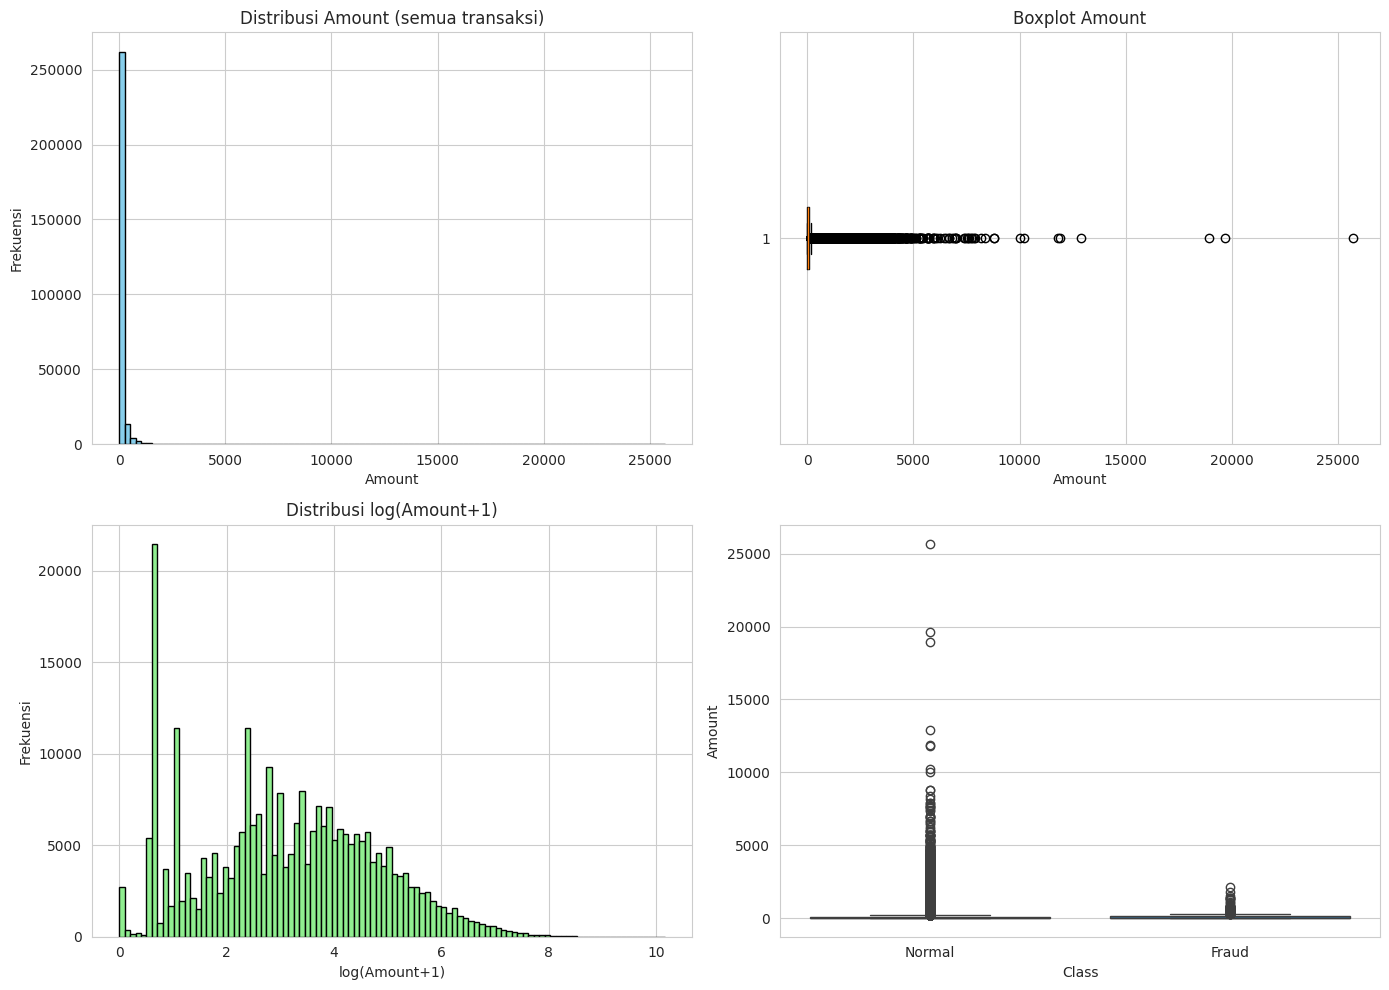

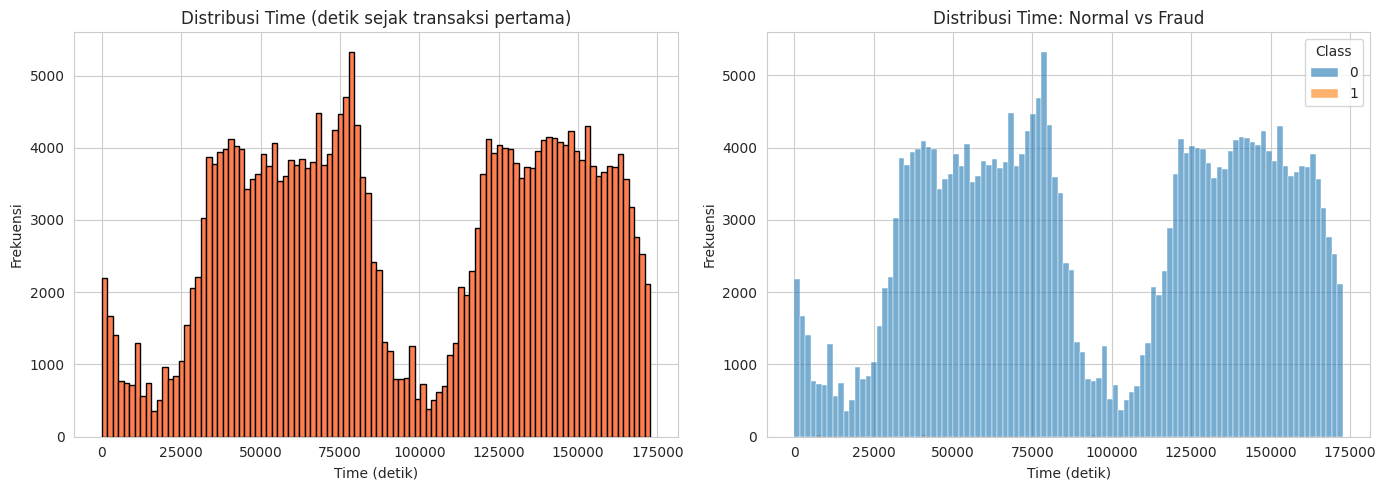

Statistik Amount:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Statistik Time:
count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


In [6]:
# EDA 
# 1. Distribusi Amount
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram Amount (semua)
axes[0,0].hist(df['Amount'], bins=100, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribusi Amount (semua transaksi)')
axes[0,0].set_xlabel('Amount')
axes[0,0].set_ylabel('Frekuensi')

# Boxplot Amount
axes[0,1].boxplot(df['Amount'], vert=False)
axes[0,1].set_title('Boxplot Amount')
axes[0,1].set_xlabel('Amount')

# Histogram Amount dengan log scale (untuk melihat ekor)
axes[1,0].hist(np.log1p(df['Amount']), bins=100, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Distribusi log(Amount+1)')
axes[1,0].set_xlabel('log(Amount+1)')
axes[1,0].set_ylabel('Frekuensi')

# Boxplot Amount berdasarkan Class (fraud vs normal)
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1,1])
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['Normal', 'Fraud'])
plt.tight_layout()
plt.show()

# 2. Distribusi Time
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Time
axes2[0].hist(df['Time'], bins=100, color='coral', edgecolor='black')
axes2[0].set_title('Distribusi Time (detik sejak transaksi pertama)')
axes2[0].set_xlabel('Time (detik)')
axes2[0].set_ylabel('Frekuensi')

# Histogram Time berdasarkan Class (overlay)
sns.histplot(data=df, x='Time', hue='Class', bins=100, alpha=0.6, ax=axes2[1])
axes2[1].set_title('Distribusi Time: Normal vs Fraud')
axes2[1].set_xlabel('Time (detik)')
axes2[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Statistik deskriptif
print("Statistik Amount:")
print(df['Amount'].describe())
print("\nStatistik Time:")
print(df['Time'].describe())


# Preprocessing (without deleting outliers)
I am not deleting any outliers because there is fraud with large amount of transaction (automaticly become outliers), every sample of fraud will be usefull for model training in my opinion 

In [7]:
# Log transform for amount 
df['Amount_log'] = np.log1p(df['Amount'])

# choosing Feature for modelling
# Kolom yang akan digunakan (drop Amount asli karena sudah diganti log)
X = df.drop(['Class', 'Amount'], axis=1)   # Amount_log tetap ada
y = df['Class']


# Spliting data (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


# Scaling
scaler = StandardScaler()
# Kolom yang akan di-scale
cols_to_scale = ['Time', 'Amount_log'] + [f'V{i}' for i in range(1,29)]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test_scaled[cols_to_scale])

Train: (198608, 30), Test: (85118, 30)


# Handling class imbalance using SMOTE

In [8]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("Setelah SMOTE:", pd.Series(y_train_resampled).value_counts())

Setelah SMOTE: Class
0    198277
1    198277
Name: count, dtype: int64


# Modelling
im using 2 models logistic regression and random forest

In [9]:
# Logistic Regression 1

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:,1]
print("Logistic Regression (1) selesai dilatih.")

Logistic Regression (1) selesai dilatih.


In [10]:
# Logistic Regression 2
lr_2 = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

lr_2.fit(X_train_resampled, y_train_resampled)
y_pred_lr2 = lr_2.predict(X_test_scaled)
y_proba_lr2 = lr_2.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (2) selesai dilatih.")

Logistic Regression (2) selesai dilatih.


In [11]:
# Random Forest 1

rf = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]
print("Random Forest (1) selesai dilatih.")

Random Forest (1) selesai dilatih.


In [12]:
# Random Forest 2

rf_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight={0: 1, 1: 4},
    random_state=42,
    n_jobs=-1
)

rf_2.fit(X_train_resampled, y_train_resampled)
y_pred_rf2 = rf_2.predict(X_test_scaled)
y_proba_rf2 = rf_2.predict_proba(X_test_scaled)[:, 1]

print("Random Forest (2) selesai dilatih.")

Random Forest (2) selesai dilatih.


In [13]:
# XGboost 1
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Training menggunakan data resampled (SMOTE)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Prediction
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
print("XGBoost (1) selesai dilatih.")


XGBoost (1) selesai dilatih.


In [14]:
# XGboost 2
xgb_2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_2.fit(X_train_resampled, y_train_resampled)
y_pred_xgb2 = xgb_2.predict(X_test_scaled)
y_proba_xgb2 = xgb_2.predict_proba(X_test_scaled)[:, 1]

print("XGBoost (2) selesai dilatih.")

XGBoost (2) selesai dilatih.


# Model evaluation


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     84976
           1       0.05      0.89      0.09       142

    accuracy                           0.97     85118
   macro avg       0.52      0.93      0.54     85118
weighted avg       1.00      0.97      0.98     85118

ROC-AUC: 0.9617
Average Precision (PR-AUC): 0.6949


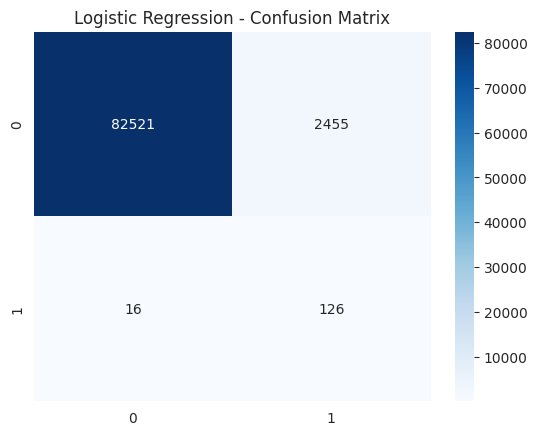


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.91      0.75      0.82       142

    accuracy                           1.00     85118
   macro avg       0.95      0.88      0.91     85118
weighted avg       1.00      1.00      1.00     85118

ROC-AUC: 0.9790
Average Precision (PR-AUC): 0.8180


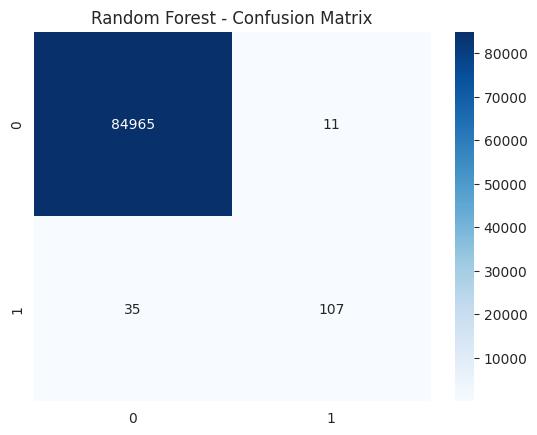


=== XGboost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.42      0.81      0.55       142

    accuracy                           1.00     85118
   macro avg       0.71      0.90      0.78     85118
weighted avg       1.00      1.00      1.00     85118

ROC-AUC: 0.9724
Average Precision (PR-AUC): 0.7832


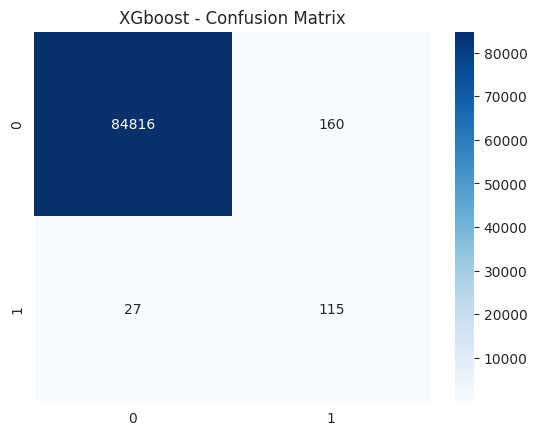


=== Logistic Regression (Recommended) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     84976
           1       0.05      0.89      0.09       142

    accuracy                           0.97     85118
   macro avg       0.52      0.93      0.54     85118
weighted avg       1.00      0.97      0.98     85118

ROC-AUC: 0.9618
Average Precision (PR-AUC): 0.6934


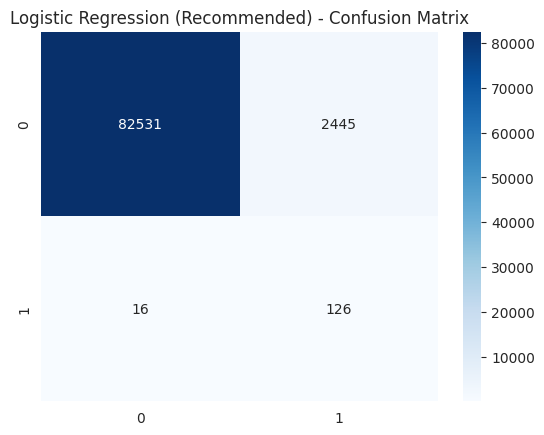


=== Random Forest (Recommended) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84976
           1       0.41      0.81      0.55       142

    accuracy                           1.00     85118
   macro avg       0.71      0.90      0.77     85118
weighted avg       1.00      1.00      1.00     85118

ROC-AUC: 0.9756
Average Precision (PR-AUC): 0.7804


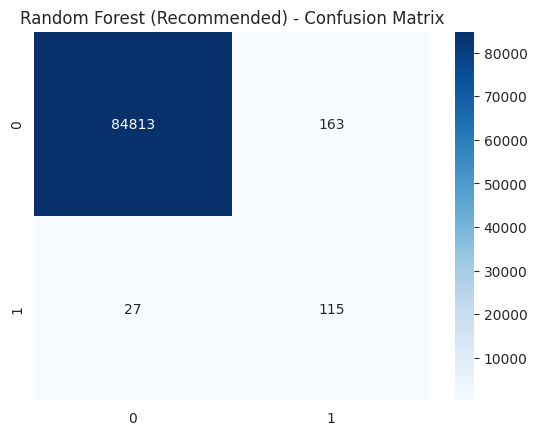


=== XGBoost (Recommended) ===
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     84976
           1       0.18      0.84      0.29       142

    accuracy                           0.99     85118
   macro avg       0.59      0.92      0.65     85118
weighted avg       1.00      0.99      1.00     85118

ROC-AUC: 0.9664
Average Precision (PR-AUC): 0.7750


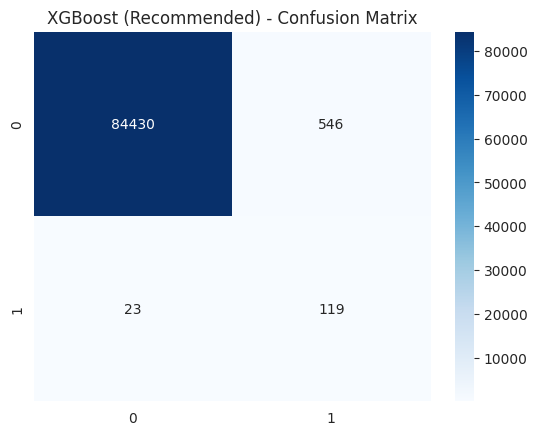

In [15]:
def evaluate_model(name, y_test, y_pred, y_proba):
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)
evaluate_model("XGboost", y_test, y_pred_xgb, y_proba_xgb)


evaluate_model("Logistic Regression (Recommended)", y_test, y_pred_lr2, y_proba_lr2)
evaluate_model("Random Forest (Recommended)", y_test, y_pred_rf2, y_proba_rf2)
evaluate_model("XGBoost (Recommended)", y_test, y_pred_xgb2, y_proba_xgb2)

## Precision-Recall Curve

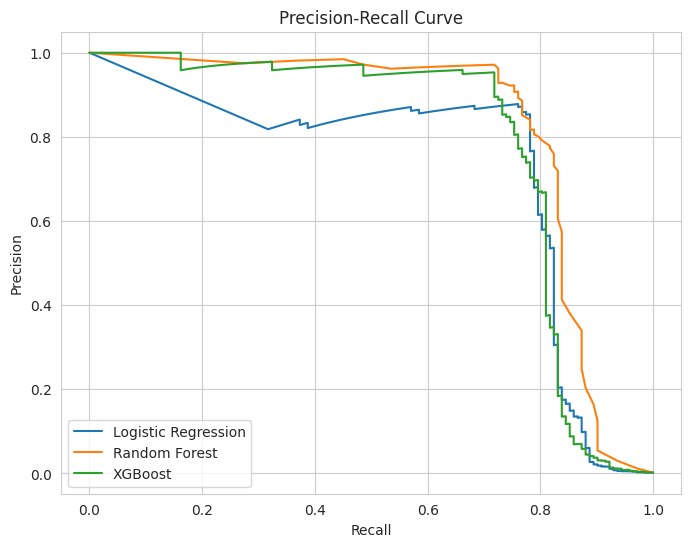

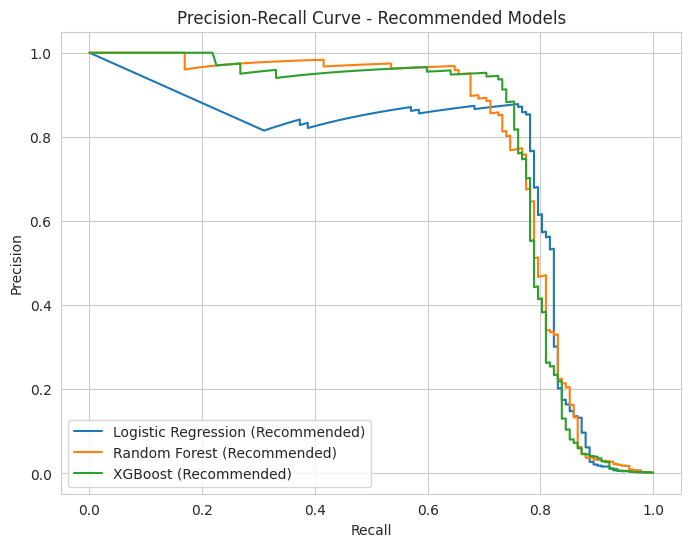

In [18]:
def plot_pr_curve(y_test, y_proba, name):
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)

plt.figure(figsize=(8,6))
plot_pr_curve(y_test, y_proba_lr, 'Logistic Regression')
plot_pr_curve(y_test, y_proba_rf, 'Random Forest')
plot_pr_curve(y_test, y_proba_xgb, 'XGBoost')
plt.show()

# Precision-Recall Curve untuk Model Rekomendasi
plt.figure(figsize=(8, 6))
plot_pr_curve(y_test, y_proba_lr2, 'Logistic Regression (Recommended)')
plot_pr_curve(y_test, y_proba_rf2, 'Random Forest (Recommended)')
plot_pr_curve(y_test, y_proba_xgb2, 'XGBoost (Recommended)')
plt.title('Precision-Recall Curve - Recommended Models')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

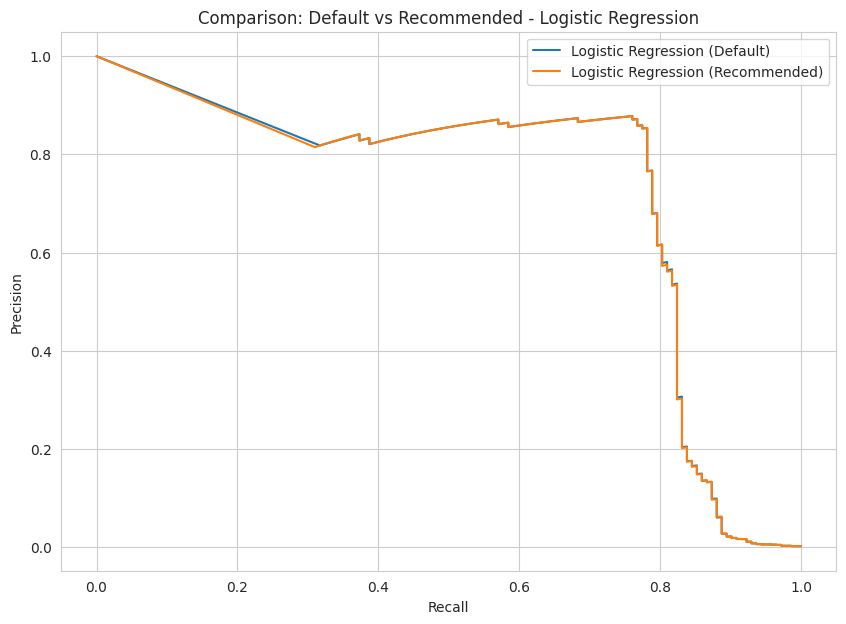

In [19]:
plt.figure(figsize=(10, 7))
plot_pr_curve(y_test, y_proba_lr, 'Logistic Regression (Default)')
plot_pr_curve(y_test, y_proba_lr2, 'Logistic Regression (Recommended)')
plt.title('Comparison: Default vs Recommended - Logistic Regression')
plt.legend()
plt.show()

# Feature Importance

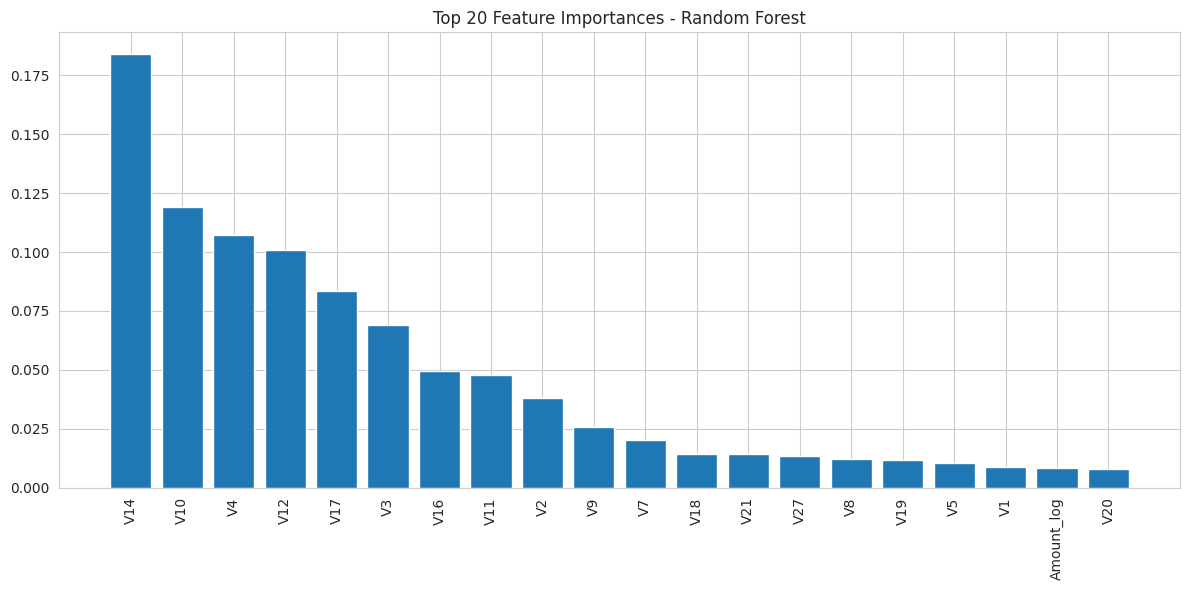

In [17]:
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(12,6))
plt.title('Top 20 Feature Importances - Random Forest')
plt.bar(range(20), importances[indices])
plt.xticks(range(20), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()